<a href="https://colab.research.google.com/github/aditibhat017-prog/cognitivefunction/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Biomarkers of Cognitive Function in Older Adults

## Week 1: Data Exploration

### Research Question

Can wearable-derived activity and rest-activity features predict cognitive performance in adults aged 60 years and older?

### Hypothesis

Greater physical activity, greater activity intensity, and more stable rest-activity patterns will be associated with better cognitive performance.

### Dataset

NHANES 2011–2014

### Primary Outcome

Digit Symbol Substitution Test (DSST)

### Secondary Outcomes

- Animal Fluency
- CERAD word learning and delayed recall

## 1. Setup

This notebook will:

1. Download NHANES data
2. Load the cognitive, wearable, and demographic datasets
3. Inspect the data structure
4. Identify relevant variables
5. Perform initial quality control

In [1]:
import os
import pandas as pd
from pathlib import Path

In [2]:
# Create folders for our data
os.makedirs("data/raw", exist_ok=True)

print("Data folder created.")

Data folder created.


In [3]:
# NHANES files we need

files = {
    "CFQ_G.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/CFQ_G.xpt",
    "PAXDAY_G.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/PAXDAY_G.xpt",
    "DEMO_G.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/DEMO_G.xpt",

    "CFQ_H.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/CFQ_H.xpt",
    "PAXDAY_H.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/PAXDAY_H.xpt",
    "DEMO_H.xpt": "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2013/DataFiles/DEMO_H.xpt"
}

print(f"We will download {len(files)} files.")

We will download 6 files.


In [4]:
import requests

for filename, url in files.items():
    output_path = f"data/raw/{filename}"

    response = requests.get(url)

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded: {filename}")

Downloaded: CFQ_G.xpt
Downloaded: PAXDAY_G.xpt
Downloaded: DEMO_G.xpt
Downloaded: CFQ_H.xpt
Downloaded: PAXDAY_H.xpt
Downloaded: DEMO_H.xpt


In [5]:
from pathlib import Path

for file in Path("data/raw").glob("*.xpt"):
    print(file, f"{file.stat().st_size / 1_000_000:.2f} MB")

data/raw/CFQ_H.xpt 0.27 MB
data/raw/PAXDAY_G.xpt 6.49 MB
data/raw/PAXDAY_H.xpt 7.32 MB
data/raw/DEMO_H.xpt 3.83 MB
data/raw/DEMO_G.xpt 3.75 MB
data/raw/CFQ_G.xpt 0.26 MB


## 2. Load NHANES Data

In [6]:
# 2011–2012

cfq_g = pd.read_sas("data/raw/CFQ_G.xpt")
pax_g = pd.read_sas("data/raw/PAXDAY_G.xpt")
demo_g = pd.read_sas("data/raw/DEMO_G.xpt")

# 2013–2014

cfq_h = pd.read_sas("data/raw/CFQ_H.xpt")
pax_h = pd.read_sas("data/raw/PAXDAY_H.xpt")
demo_h = pd.read_sas("data/raw/DEMO_H.xpt")

In [7]:
print("2011–2012")
print("Cognitive:", cfq_g.shape)
print("Activity:", pax_g.shape)
print("Demographics:", demo_g.shape)

print("\n2013–2014")
print("Cognitive:", cfq_h.shape)
print("Activity:", pax_h.shape)
print("Demographics:", demo_h.shape)

2011–2012
Cognitive: (1687, 19)
Activity: (61168, 15)
Demographics: (9756, 48)

2013–2014
Cognitive: (1785, 19)
Activity: (69018, 15)
Demographics: (10175, 47)


In [8]:
cfq_h.head()

,SEQN,CFASTAT,CFALANG,CFDCCS,CFDCRNC,CFDCST1,CFDCST2,CFDCST3,CFDCSR,CFDCIT1,CFDCIT2,CFDCIT3,CFDCIR,CFDAPP,CFDARNC,CFDAST,CFDDPP,CFDDRNC,CFDDS
0,73557.0,1.0,1.0,1.0,NaN,4.0,7.0,9.0,7.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,16.0,1.0,NaN,54.0
1,73559.0,1.0,1.0,1.0,NaN,4.0,8.0,7.0,6.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,13.0,1.0,NaN,63.0
2,73561.0,1.0,1.0,1.0,NaN,6.0,10.0,10.0,10.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,19.0,1.0,NaN,59.0
3,73564.0,1.0,1.0,1.0,NaN,5.0,6.0,6.0,7.0,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,1.0,NaN,20.0,1.0,NaN,79.0
4,73567.0,1.0,1.0,1.0,NaN,6.0,9.0,10.0,10.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.0,NaN,15.0,1.0,NaN,30.0


In [9]:
cfq_h.columns.tolist()

['SEQN',
 'CFASTAT',
 'CFALANG',
 'CFDCCS',
 'CFDCRNC',
 'CFDCST1',
 'CFDCST2',
 'CFDCST3',
 'CFDCSR',
 'CFDCIT1',
 'CFDCIT2',
 'CFDCIT3',
 'CFDCIR',
 'CFDAPP',
 'CFDARNC',
 'CFDAST',
 'CFDDPP',
 'CFDDRNC',
 'CFDDS']

In [10]:
[c for c in cfq_h.columns if c.startswith("CFD")]

['CFDCCS',
 'CFDCRNC',
 'CFDCST1',
 'CFDCST2',
 'CFDCST3',
 'CFDCSR',
 'CFDCIT1',
 'CFDCIT2',
 'CFDCIT3',
 'CFDCIR',
 'CFDAPP',
 'CFDARNC',
 'CFDAST',
 'CFDDPP',
 'CFDDRNC',
 'CFDDS']

In [11]:
pax_h.head()

,SEQN,PAXDAYD,PAXDAYWD,PAXSSNDP,PAXMSTD,PAXTMD,PAXAISMD,PAXVMD,PAXMTSD,PAXWWMD,PAXSWMD,PAXNWMD,PAXUMD,PAXLXSD,PAXQFD
0,73557.0,b'1',b'3',5.397605e-79,b'16:30:00',450.0,915200.0,450.0,4576.422,2.370000e+02,2.200000e+01,174.0,17.0,1.470493e+05,5.397605e-79
1,73557.0,b'2',b'4',2.160000e+06,b' 0:00:00',1440.0,2989920.0,1440.0,12222.152,7.440000e+02,1.130000e+02,546.0,37.0,1.733408e+05,5.397605e-79
2,73557.0,b'3',b'5',9.072000e+06,b' 0:00:00',1440.0,3307840.0,1440.0,3158.922,1.470000e+02,5.397605e-79,1287.0,6.0,8.340733e+04,5.397605e-79
3,73557.0,b'4',b'6',1.598400e+07,b' 0:00:00',1440.0,6860400.0,1440.0,23.641,5.397605e-79,5.397605e-79,1439.0,1.0,5.397605e-79,5.397605e-79
4,73557.0,b'5',b'7',2.289600e+07,b' 0:00:00',1440.0,3968640.0,1440.0,8879.010,5.040000e+02,9.800000e+01,822.0,16.0,3.864985e+04,5.397605e-79


In [12]:
[c for c in pax_h.columns if c.startswith("PAX")]

['PAXDAYD',
 'PAXDAYWD',
 'PAXSSNDP',
 'PAXMSTD',
 'PAXTMD',
 'PAXAISMD',
 'PAXVMD',
 'PAXMTSD',
 'PAXWWMD',
 'PAXSWMD',
 'PAXNWMD',
 'PAXUMD',
 'PAXLXSD',
 'PAXQFD']

In [13]:
pax_h[
    [
        "SEQN",
        "PAXDAYD",
        "PAXMTSD",
        "PAXVMD",
        "PAXWWMD",
        "PAXSWMD"
    ]
].head()

,SEQN,PAXDAYD,PAXMTSD,PAXVMD,PAXWWMD,PAXSWMD
0,73557.0,b'1',4576.422,450.0,2.370000e+02,2.200000e+01
1,73557.0,b'2',12222.152,1440.0,7.440000e+02,1.130000e+02
2,73557.0,b'3',3158.922,1440.0,1.470000e+02,5.397605e-79
3,73557.0,b'4',23.641,1440.0,5.397605e-79,5.397605e-79
4,73557.0,b'5',8879.010,1440.0,5.040000e+02,9.800000e+01


In [14]:
demo_h.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557.0,8.0,2.0,1.0,69.0,NaN,4.0,4.0,1.0,NaN,...,3.0,4.0,NaN,13281.237386,13481.042095,1.0,112.0,4.0,4.0,0.84
1,73558.0,8.0,2.0,1.0,54.0,NaN,3.0,3.0,1.0,NaN,...,3.0,1.0,1.0,23682.057386,24471.769625,1.0,108.0,7.0,7.0,1.78
2,73559.0,8.0,2.0,1.0,72.0,NaN,3.0,3.0,2.0,NaN,...,4.0,1.0,3.0,57214.803319,57193.285376,1.0,109.0,10.0,10.0,4.51
3,73560.0,8.0,2.0,1.0,9.0,NaN,3.0,3.0,1.0,119.0,...,3.0,1.0,4.0,55201.178592,55766.512438,2.0,109.0,9.0,9.0,2.52
4,73561.0,8.0,2.0,2.0,73.0,NaN,3.0,3.0,1.0,NaN,...,5.0,1.0,5.0,63709.667069,65541.871229,2.0,116.0,15.0,15.0,5.00


In [15]:
demo_h[
    [
        "SEQN",
        "RIDAGEYR",
        "RIAGENDR",
        "DMDEDUC2"
    ]
].head()

,SEQN,RIDAGEYR,RIAGENDR,DMDEDUC2
0,73557.0,69.0,1.0,3.0
1,73558.0,54.0,1.0,3.0
2,73559.0,72.0,1.0,4.0
3,73560.0,9.0,1.0,NaN
4,73561.0,73.0,2.0,5.0


## 3. Inspecting Cognitive Variables

In [16]:
# Inspect the primary and secondary cognitive outcomes

cognitive_vars = [
    "SEQN",
    "CFDDS",
    "CFDAST",
    "CFDCSR",
    "CFDCST1",
    "CFDCST2",
    "CFDCST3"
]

cfq_h[cognitive_vars].describe()

,SEQN,CFDDS,CFDAST,CFDCSR,CFDCST1,CFDCST2,CFDCST3
count,1785.000000,1.592000e+03,1661.000000,1.672000e+03,1.681000e+03,1.678000e+03,1.674000e+03
mean,78665.612885,4.595101e+01,16.427453,6.084330e+00,4.759667e+00,6.802741e+00,7.682198e+00
std,2965.804479,1.723167e+01,5.551864,2.392026e+00,1.746238e+00,1.955636e+00,1.927702e+00
min,73557.000000,5.397605e-79,3.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,76149.000000,3.300000e+01,12.000000,5.000000e+00,4.000000e+00,6.000000e+00,7.000000e+00
50%,78640.000000,4.600000e+01,16.000000,6.000000e+00,5.000000e+00,7.000000e+00,8.000000e+00
75%,81269.000000,5.800000e+01,20.000000,8.000000e+00,6.000000e+00,8.000000e+00,9.000000e+00
max,83724.000000,1.050000e+02,39.000000,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01


In [17]:
cfq_h[cognitive_vars].isna().sum()

,0
SEQN,0
CFDDS,193
CFDAST,124
CFDCSR,113
CFDCST1,104
CFDCST2,107
CFDCST3,111


## 4. Inspecting Wearable Variables

In [18]:
wearable_vars = [
    "SEQN",
    "PAXDAYD",
    "PAXMTSD",
    "PAXVMD",
    "PAXWWMD",
    "PAXSWMD",
    "PAXNWMD",
    "PAXUMD",
    "PAXQFD"
]

pax_h[wearable_vars].describe()

,SEQN,PAXMTSD,PAXVMD,PAXWWMD,PAXSWMD,PAXNWMD,PAXUMD,PAXQFD
count,69018.000000,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04
mean,78667.985540,1.126228e+04,1.274297e+03,6.804351e+02,3.770694e+02,1.742785e+02,4.251432e+01,4.556159e+00
std,2935.050609,7.074941e+03,3.380953e+02,3.500921e+02,2.190723e+02,3.642156e+02,2.689863e+01,7.068316e+01
min,73557.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,76129.000000,5.669873e+03,1.434000e+03,4.110000e+02,2.430000e+02,5.397605e-79,2.400000e+01,5.397605e-79
50%,78703.000000,1.157286e+04,1.440000e+03,8.320000e+02,4.180000e+02,5.397605e-79,4.000000e+01,5.397605e-79
75%,81199.000000,1.633570e+04,1.440000e+03,9.440000e+02,5.100000e+02,1.040000e+02,5.900000e+01,5.397605e-79
max,83731.000000,4.494209e+04,1.440000e+03,1.438000e+03,1.440000e+03,1.440000e+03,2.510000e+02,3.110000e+03


In [19]:
pax_h[wearable_vars].isna().sum()

,0
SEQN,0
PAXDAYD,0
PAXMTSD,0
PAXVMD,0
PAXWWMD,0
PAXSWMD,0
PAXNWMD,0
PAXUMD,0
PAXQFD,0


In [20]:
pax_h[wearable_vars].dtypes

,0
SEQN,float64
PAXDAYD,object
PAXMTSD,float64
PAXVMD,float64
PAXWWMD,float64
PAXSWMD,float64
PAXNWMD,float64
PAXUMD,float64
PAXQFD,float64


In [21]:
pax_h["PAXMTSD"].sort_values().head(20)

,PAXMTSD
39766,5.397605e-79
2957,5.397605e-79
2958,5.397605e-79
35966,5.397605e-79
35967,5.397605e-79
60083,5.397605e-79
2690,5.397605e-79
24751,5.397605e-79
15846,5.397605e-79
15847,5.397605e-79


In [22]:
pax_h["PAXMTSD"].sort_values(ascending=False).head(20)

,PAXMTSD
68461,44942.093
7431,43921.869
36422,41011.590
9944,40990.555
28941,40766.416
11658,40734.680
56341,40572.940
32241,40110.740
56807,39872.828
45571,39565.446


In [23]:
pax_h["PAXVMD"].value_counts().sort_index().head(20)

,count
PAXVMD,
5.397605e-79,35
1.000000e+00,3
2.000000e+00,1
3.000000e+00,1
4.000000e+00,1
6.000000e+00,2
1.000000e+01,2
1.100000e+01,1
3.300000e+01,1


In [24]:
pax_h["PAXVMD"].describe()

,PAXVMD
count,6.901800e+04
mean,1.274297e+03
std,3.380953e+02
min,5.397605e-79
25%,1.434000e+03
50%,1.440000e+03
75%,1.440000e+03
max,1.440000e+03


In [25]:
days_per_person = pax_h.groupby("SEQN")["PAXDAYD"].nunique()

days_per_person.describe()

,PAXDAYD
count,7776.000000
mean,8.875772
std,0.795324
min,1.000000
25%,9.000000
50%,9.000000
75%,9.000000
max,9.000000


In [26]:
days_per_person.value_counts().sort_index()

,count
PAXDAYD,
1,7
2,37
3,30
4,31
5,30
6,31
7,30
8,43
9,7537


In [27]:
cfq_h[cognitive_vars].isna().sum()

,0
SEQN,0
CFDDS,193
CFDAST,124
CFDCSR,113
CFDCST1,104
CFDCST2,107
CFDCST3,111


In [28]:
pax_h[wearable_vars].describe()

,SEQN,PAXMTSD,PAXVMD,PAXWWMD,PAXSWMD,PAXNWMD,PAXUMD,PAXQFD
count,69018.000000,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04,6.901800e+04
mean,78667.985540,1.126228e+04,1.274297e+03,6.804351e+02,3.770694e+02,1.742785e+02,4.251432e+01,4.556159e+00
std,2935.050609,7.074941e+03,3.380953e+02,3.500921e+02,2.190723e+02,3.642156e+02,2.689863e+01,7.068316e+01
min,73557.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,76129.000000,5.669873e+03,1.434000e+03,4.110000e+02,2.430000e+02,5.397605e-79,2.400000e+01,5.397605e-79
50%,78703.000000,1.157286e+04,1.440000e+03,8.320000e+02,4.180000e+02,5.397605e-79,4.000000e+01,5.397605e-79
75%,81199.000000,1.633570e+04,1.440000e+03,9.440000e+02,5.100000e+02,1.040000e+02,5.900000e+01,5.397605e-79
max,83731.000000,4.494209e+04,1.440000e+03,1.438000e+03,1.440000e+03,1.440000e+03,2.510000e+02,3.110000e+03


In [29]:
pax_h["PAXMTSD"].sort_values().head(20)

,PAXMTSD
39766,5.397605e-79
2957,5.397605e-79
2958,5.397605e-79
35966,5.397605e-79
35967,5.397605e-79
60083,5.397605e-79
2690,5.397605e-79
24751,5.397605e-79
15846,5.397605e-79
15847,5.397605e-79


In [30]:
pax_h["PAXMTSD"].sort_values(ascending=False).head(20)

,PAXMTSD
68461,44942.093
7431,43921.869
36422,41011.590
9944,40990.555
28941,40766.416
11658,40734.680
56341,40572.940
32241,40110.740
56807,39872.828
45571,39565.446


In [31]:
days_per_person.value_counts().sort_index()

,count
PAXDAYD,
1,7
2,37
3,30
4,31
5,30
6,31
7,30
8,43
9,7537


## 5. Data Cleaning and Quality Control

The NHANES physical activity monitor data contain SAS missing-value encodings that must be converted to standard missing values before analysis. Wearable observations will then be evaluated based on valid monitoring time and day of wear.

In [32]:
# SAS missing values are represented by this very small number
SAS_MISSING = 5.397605e-79

# Make copies before cleaning
pax_clean = pax_h.copy()
cfq_clean = cfq_h.copy()
demo_clean = demo_h.copy()

# Replace SAS missing values with standard pandas NaN
pax_clean = pax_clean.replace(SAS_MISSING, pd.NA)
cfq_clean = cfq_clean.replace(SAS_MISSING, pd.NA)
demo_clean = demo_clean.replace(SAS_MISSING, pd.NA)

In [33]:
pax_clean[wearable_vars].isna().sum()

,0
SEQN,0
PAXDAYD,0
PAXMTSD,0
PAXVMD,0
PAXWWMD,0
PAXSWMD,0
PAXNWMD,0
PAXUMD,0
PAXQFD,0


In [34]:
pax_clean["PAXDAYD"] = (
    pax_clean["PAXDAYD"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

In [35]:
pax_clean["PAXDAYD"].value_counts().sort_index()

,count
PAXDAYD,
1.0,7776
2.0,7769
3.0,7732
4.0,7702
5.0,7671
6.0,7641
7.0,7610
8.0,7580
9.0,7537


In [36]:
# Define a valid monitoring day as >= 600 valid minutes
pax_clean["valid_day"] = pax_clean["PAXVMD"] >= 600

pax_clean["valid_day"].value_counts()

,count
valid_day,
True,64548
False,4470


In [37]:
valid_days_per_person = (
    pax_clean.groupby("SEQN")["valid_day"]
    .sum()
)

valid_days_per_person.describe()

,valid_day
count,7776.000000
mean,8.300926
std,1.028334
min,0.000000
25%,8.000000
50%,8.000000
75%,9.000000
max,9.000000


In [38]:
valid_days_per_person.value_counts().sort_index()

,count
valid_day,
0,13
1,30
2,40
3,30
4,32
5,34
6,43
7,42
8,4110


In [39]:
participant_valid_days = (
    valid_days_per_person >= 4
)

participant_valid_days.value_counts()

,count
valid_day,
True,7663
False,113


## 6. Participant-Level Wearable Feature Engineering

Daily physical activity measurements are aggregated into participant-level features so that they can be aligned with the participant's cognitive assessment.

In [40]:
# Keep only valid monitoring days
valid_pax = pax_clean[pax_clean["valid_day"]].copy()

# Create participant-level wearable features
wearable_features = (
    valid_pax
    .groupby("SEQN")
    .agg(
        mean_daily_activity=("PAXMTSD", "mean"),
        activity_sd=("PAXMTSD", "std"),
        mean_valid_minutes=("PAXVMD", "mean"),
        mean_wake_wear_minutes=("PAXWWMD", "mean"),
        mean_sleep_wear_minutes=("PAXSWMD", "mean"),
        mean_nonwear_minutes=("PAXNWMD", "mean"),
        mean_unknown_minutes=("PAXUMD", "mean"),
        valid_days=("valid_day", "sum")
    )
    .reset_index()
)

In [41]:
wearable_features.head()

,SEQN,mean_daily_activity,activity_sd,mean_valid_minutes,mean_wake_wear_minutes,mean_sleep_wear_minutes,mean_nonwear_minutes,mean_unknown_minutes,valid_days
0,73557.0,6593.629500,4922.349140,1384.875000,365.000000,90.375000,916.000000,13.500000,8
1,73558.0,9253.650250,3823.789574,1422.000000,750.375000,428.250000,177.750000,65.625000,8
2,73559.0,8005.963333,3505.958665,1281.000000,658.888889,511.111111,43.555556,67.444444,9
3,73560.0,22423.463625,3181.191560,1387.875000,842.375000,452.500000,69.000000,24.000000,8
4,73561.0,6470.660889,2572.262614,1280.666667,680.111111,501.000000,25.777778,73.777778,9


In [42]:
wearable_features["activity_cv"] = (
    wearable_features["activity_sd"] /
    wearable_features["mean_daily_activity"]
)

In [43]:
wearable_features.describe()

,SEQN,mean_daily_activity,activity_sd,mean_valid_minutes,mean_wake_wear_minutes,mean_sleep_wear_minutes,mean_nonwear_minutes,mean_unknown_minutes,valid_days,activity_cv
count,7763.000000,7763.000000,7733.000000,7763.000000,7.763000e+03,7.763000e+03,7.763000e+03,7.763000e+03,7763.000000,7733.000000
mean,78666.140538,11842.444639,5123.933342,1341.253723,7.130122e+02,3.990586e+02,1.845630e+02,4.461986e+01,8.314827,0.506216
std,2935.417300,4680.045688,2050.414870,73.244978,1.975470e+02,1.354744e+02,2.865570e+02,1.907936e+01,0.971413,0.340514
min,73557.000000,0.674500,1.379176,611.000000,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000,0.001260
25%,76126.500000,8935.958819,3728.363386,1280.666667,6.709444e+02,3.487778e+02,2.688889e+01,3.277778e+01,8.000000,0.372522
50%,78701.000000,11894.506875,5031.971285,1384.875000,7.732500e+02,4.166250e+02,6.912500e+01,4.312500e+01,8.000000,0.416449
75%,81194.500000,15011.053444,6432.133124,1392.375000,8.294375e+02,4.756667e+02,1.779375e+02,5.577778e+01,9.000000,0.492427
max,83731.000000,29205.625556,14911.841518,1440.000000,1.172556e+03,1.362625e+03,1.422375e+03,1.611250e+02,9.000000,2.989025


In [44]:
wearable_features.isna().sum()

,0
SEQN,0
mean_daily_activity,0
activity_sd,30
mean_valid_minutes,0
mean_wake_wear_minutes,0
mean_sleep_wear_minutes,0
mean_nonwear_minutes,0
mean_unknown_minutes,0
valid_days,0
activity_cv,30


In [45]:
wearable_features = wearable_features[
    wearable_features["valid_days"] >= 4
].copy()

In [46]:
wearable_features.shape

(7663, 10)

In [47]:
demo_analysis = demo_clean[
    [
        "SEQN",
        "RIDAGEYR",
        "RIAGENDR",
        "DMDEDUC2"
    ]
].copy()

In [48]:
cognitive_analysis = cfq_clean[
    [
        "SEQN",
        "CFDDS",
        "CFDAST",
        "CFDCSR",
        "CFDCST1",
        "CFDCST2",
        "CFDCST3"
    ]
].copy()

In [49]:
analysis_df = (
    cognitive_analysis
    .merge(demo_analysis, on="SEQN", how="left")
    .merge(wearable_features, on="SEQN", how="inner")
)

In [50]:
analysis_df.shape

(1536, 19)

In [51]:
analysis_df.head()

,SEQN,CFDDS,CFDAST,CFDCSR,CFDCST1,CFDCST2,CFDCST3,RIDAGEYR,RIAGENDR,DMDEDUC2,mean_daily_activity,activity_sd,mean_valid_minutes,mean_wake_wear_minutes,mean_sleep_wear_minutes,mean_nonwear_minutes,mean_unknown_minutes,valid_days,activity_cv
0,73557.0,54.0,16.0,7.0,4.0,7.0,9.0,69.0,1.0,3.0,6593.629500,4922.349140,1384.875000,365.000000,90.375000,916.000000,13.500000,8,0.746531
1,73559.0,63.0,13.0,6.0,4.0,8.0,7.0,72.0,1.0,4.0,8005.963333,3505.958665,1281.000000,658.888889,511.111111,43.555556,67.444444,9,0.437918
2,73561.0,59.0,19.0,10.0,6.0,10.0,10.0,73.0,2.0,5.0,6470.660889,2572.262614,1280.666667,680.111111,501.000000,25.777778,73.777778,9,0.397527
3,73564.0,79.0,20.0,7.0,5.0,6.0,6.0,61.0,2.0,5.0,9435.993222,3708.339374,1281.000000,689.222222,512.000000,24.777778,55.000000,9,0.392999
4,73567.0,30.0,15.0,10.0,6.0,9.0,10.0,65.0,1.0,2.0,8461.177875,5355.213032,1392.375000,609.250000,376.750000,381.500000,24.875000,8,0.632916


In [52]:
analysis_df = analysis_df[
    analysis_df["RIDAGEYR"] >= 60
].copy()

In [53]:
analysis_df.shape

(1536, 19)

In [54]:
analysis_df[
    [
        "RIDAGEYR",
        "RIAGENDR",
        "DMDEDUC2",
        "CFDDS",
        "CFDAST",
        "CFDCSR",
        "mean_daily_activity",
        "activity_sd",
        "activity_cv",
        "mean_valid_minutes",
        "mean_wake_wear_minutes",
        "mean_sleep_wear_minutes",
        "valid_days"
    ]
].describe()

,RIDAGEYR,RIAGENDR,DMDEDUC2,CFDDS,CFDAST,CFDCSR,mean_daily_activity,activity_sd,activity_cv,mean_valid_minutes,mean_wake_wear_minutes,mean_sleep_wear_minutes,valid_days
count,1536.000000,1536.000000,1536.000000,1.389000e+03,1444.000000,1.456000e+03,1536.000000,1536.000000,1536.000000,1536.000000,1.536000e+03,1.536000e+03,1536.000000
mean,70.027344,1.522135,3.353516,4.622030e+01,16.557479,6.114698e+00,9644.948806,3773.599103,0.418897,1339.198140,7.266680e+02,4.534552e+02,8.436849
std,6.768044,0.499672,1.316159,1.712639e+01,5.525235,2.386365e+00,3404.392134,1573.580353,0.225970,62.369443,1.513059e+02,1.282354e+02,0.616745
min,60.000000,1.000000,1.000000,5.397605e-79,3.000000,5.397605e-79,1.344667,2.820798,0.082633,749.800000,5.397605e-79,5.397605e-79,4.000000
25%,64.000000,1.000000,2.000000,3.400000e+01,13.000000,5.000000e+00,7444.205021,2686.907637,0.344194,1281.000000,6.700764e+02,3.904722e+02,8.000000
50%,69.000000,2.000000,3.500000,4.600000e+01,16.000000,6.000000e+00,9521.891667,3638.771909,0.390544,1383.812500,7.545556e+02,4.524375e+02,8.000000
75%,76.000000,2.000000,4.000000,5.800000e+01,20.000000,8.000000e+00,11741.957000,4748.366985,0.433320,1392.375000,8.175000e+02,5.180556e+02,9.000000
max,80.000000,2.000000,9.000000,1.050000e+02,36.000000,1.000000e+01,24837.395750,12576.852218,2.909470,1440.000000,1.025222e+03,1.086750e+03,9.000000


In [55]:
analysis_df.isna().sum()

,0
SEQN,0
CFDDS,147
CFDAST,92
CFDCSR,80
CFDCST1,73
CFDCST2,74
CFDCST3,78
RIDAGEYR,0
RIAGENDR,0
DMDEDUC2,0


In [56]:
# Create primary DSST analysis sample
dsst_df = analysis_df.dropna(
    subset=["CFDDS"]
).copy()

print("Full analysis dataset:", analysis_df.shape)
print("DSST analysis dataset:", dsst_df.shape)

Full analysis dataset: (1536, 19)
DSST analysis dataset: (1389, 19)


In [57]:
dsst_df.isna().sum()

,0
SEQN,0
CFDDS,0
CFDAST,15
CFDCSR,2
CFDCST1,0
CFDCST2,1
CFDCST3,2
RIDAGEYR,0
RIAGENDR,0
DMDEDUC2,0


## 7. Primary Analysis Sample

The primary analysis uses the Digit Symbol Substitution Test (DSST) as the cognitive outcome. Participants without a valid DSST score are excluded from the primary analysis but retained in the master dataset for secondary cognitive analyses.

In [58]:
dsst_df[
    [
        "RIDAGEYR",
        "RIAGENDR",
        "DMDEDUC2",
        "CFDDS",
        "mean_daily_activity",
        "activity_sd",
        "activity_cv",
        "mean_valid_minutes",
        "mean_wake_wear_minutes",
        "mean_sleep_wear_minutes",
        "valid_days"
    ]
].describe()

,RIDAGEYR,RIAGENDR,DMDEDUC2,CFDDS,mean_daily_activity,activity_sd,activity_cv,mean_valid_minutes,mean_wake_wear_minutes,mean_sleep_wear_minutes,valid_days
count,1389.000000,1389.000000,1389.000000,1.389000e+03,1389.000000,1389.000000,1389.000000,1389.000000,1.389000e+03,1.389000e+03,1389.000000
mean,69.668107,1.516919,3.452844,4.622030e+01,9831.647230,3842.482958,0.415003,1337.760577,7.344260e+02,4.507418e+02,8.442765
std,6.638135,0.499894,1.246945,1.712639e+01,3305.380920,1526.995809,0.214156,62.688916,1.434818e+02,1.220131e+02,0.628742
min,60.000000,1.000000,1.000000,5.397605e-79,1.344667,2.820798,0.085101,749.800000,5.397605e-79,5.397605e-79,4.000000
25%,64.000000,1.000000,3.000000,3.400000e+01,7718.448556,2814.574690,0.346903,1281.000000,6.801111e+02,3.897500e+02,8.000000
50%,69.000000,2.000000,4.000000,4.600000e+01,9722.239000,3714.376036,0.391532,1367.250000,7.590000e+02,4.505000e+02,8.000000
75%,75.000000,2.000000,4.000000,5.800000e+01,11863.090444,4769.571727,0.431508,1392.375000,8.201111e+02,5.130000e+02,9.000000
max,80.000000,2.000000,9.000000,1.050000e+02,24837.395750,12576.852218,2.909470,1440.000000,1.025222e+03,1.086750e+03,9.000000


In [59]:
print("Participants:", len(dsst_df))

print("\nAge range:")
print(dsst_df["RIDAGEYR"].min(), "-", dsst_df["RIDAGEYR"].max())

print("\nDSST range:")
print(dsst_df["CFDDS"].min(), "-", dsst_df["CFDDS"].max())

print("\nSex:")
print(dsst_df["RIAGENDR"].value_counts())

print("\nEducation:")
print(dsst_df["DMDEDUC2"].value_counts().sort_index())

print("\nValid wearable days:")
print(dsst_df["valid_days"].value_counts().sort_index())

Participants: 1389

Age range:
60.0 - 80.0

DSST range:
5.397605346934028e-79 - 105.0

Sex:
RIAGENDR
2.0    718
1.0    671
Name: count, dtype: int64

Education:
DMDEDUC2
1.0    126
2.0    185
3.0    346
4.0    402
5.0    329
9.0      1
Name: count, dtype: int64

Valid wearable days:
valid_days
4      5
5      4
6      8
7      5
8    699
9    668
Name: count, dtype: int64


In [60]:
import numpy as np

# Convert extremely small SAS missing-value representations to NaN
for df in [pax_clean, cfq_clean, demo_clean]:
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        df.loc[df[col].abs() < 1e-50, col] = np.nan

In [61]:
cfq_clean["CFDDS"].describe()

,CFDDS
count,1590.000000
mean,46.008805
std,17.165171
min,2.000000
25%,33.000000
50%,46.000000
75%,58.000000
max,105.000000


In [62]:
demo_clean["DMDEDUC2"] = demo_clean["DMDEDUC2"].replace(
    [7, 9],
    np.nan
)

In [63]:
demo_analysis

,SEQN,RIDAGEYR,RIAGENDR,DMDEDUC2
0,73557.0,69.0,1.0,3.0
1,73558.0,54.0,1.0,3.0
2,73559.0,72.0,1.0,4.0
3,73560.0,9.0,1.0,NaN
4,73561.0,73.0,2.0,5.0
...,...,...,...,...
10170,83727.0,26.0,1.0,5.0
10171,83728.0,2.0,2.0,NaN
10172,83729.0,42.0,2.0,5.0
10173,83730.0,7.0,1.0,NaN


In [64]:
cognitive_analysis

,SEQN,CFDDS,CFDAST,CFDCSR,CFDCST1,CFDCST2,CFDCST3
0,73557.0,54.0,16.0,7.0,4.0,7.0,9.0
1,73559.0,63.0,13.0,6.0,4.0,8.0,7.0
2,73561.0,59.0,19.0,10.0,6.0,10.0,10.0
3,73564.0,79.0,20.0,7.0,5.0,6.0,6.0
4,73567.0,30.0,15.0,10.0,6.0,9.0,10.0
...,...,...,...,...,...,...,...
1780,83712.0,55.0,16.0,9.0,8.0,8.0,9.0
1781,83717.0,NaN,12.0,6.0,1.0,6.0,9.0
1782,83718.0,55.0,23.0,5.0,5.0,7.0,8.0
1783,83723.0,44.0,8.0,3.0,3.0,4.0,5.0


In [65]:
dsst_df = analysis_df.dropna(
    subset=["CFDDS", "DMDEDUC2"]
).copy()

In [66]:
print("Participants:", len(dsst_df))

print("\nAge range:")
print(dsst_df["RIDAGEYR"].min(), "-", dsst_df["RIDAGEYR"].max())

print("\nDSST range:")
print(dsst_df["CFDDS"].min(), "-", dsst_df["CFDDS"].max())

print("\nSex:")
print(dsst_df["RIAGENDR"].value_counts())

print("\nEducation:")
print(dsst_df["DMDEDUC2"].value_counts().sort_index())

print("\nValid wearable days:")
print(dsst_df["valid_days"].value_counts().sort_index())

Participants: 1389

Age range:
60.0 - 80.0

DSST range:
5.397605346934028e-79 - 105.0

Sex:
RIAGENDR
2.0    718
1.0    671
Name: count, dtype: int64

Education:
DMDEDUC2
1.0    126
2.0    185
3.0    346
4.0    402
5.0    329
9.0      1
Name: count, dtype: int64

Valid wearable days:
valid_days
4      5
5      4
6      8
7      5
8    699
9    668
Name: count, dtype: int64


In [67]:
import numpy as np

# Clean SAS missing-value representations from analysis dataset
numeric_cols = analysis_df.select_dtypes(include="number").columns

for col in numeric_cols:
    analysis_df.loc[
        analysis_df[col].abs() < 1e-50,
        col
    ] = np.nan

# NHANES education codes:
# 7 = Refused
# 9 = Don't know
analysis_df["DMDEDUC2"] = analysis_df["DMDEDUC2"].replace(
    [7, 9],
    np.nan
)

In [68]:
print("DSST minimum:", analysis_df["CFDDS"].min())

print("\nEducation values:")
print(
    analysis_df["DMDEDUC2"]
    .value_counts(dropna=False)
    .sort_index()
)

DSST minimum: 4.0

Education values:
DMDEDUC2
1.0    185
2.0    212
3.0    371
4.0    423
5.0    342
NaN      3
Name: count, dtype: int64


In [69]:
dsst_df = analysis_df.dropna(
    subset=[
        "CFDDS",
        "DMDEDUC2"
    ]
).copy()

In [70]:
print("Participants:", len(dsst_df))

print("\nAge range:")
print(
    dsst_df["RIDAGEYR"].min(),
    "-",
    dsst_df["RIDAGEYR"].max()
)

print("\nDSST range:")
print(
    dsst_df["CFDDS"].min(),
    "-",
    dsst_df["CFDDS"].max()
)

print("\nSex:")
print(dsst_df["RIAGENDR"].value_counts())

print("\nEducation:")
print(
    dsst_df["DMDEDUC2"]
    .value_counts()
    .sort_index()
)

print("\nValid wearable days:")
print(
    dsst_df["valid_days"]
    .value_counts()
    .sort_index()
)

Participants: 1386

Age range:
60.0 - 80.0

DSST range:
4.0 - 105.0

Sex:
RIAGENDR
2.0    717
1.0    669
Name: count, dtype: int64

Education:
DMDEDUC2
1.0    125
2.0    185
3.0    345
4.0    402
5.0    329
Name: count, dtype: int64

Valid wearable days:
valid_days
4.0      5
5.0      4
6.0      8
7.0      5
8.0    698
9.0    666
Name: count, dtype: int64


## 8. Exploratory Data Analysis

Exploratory data analysis was performed to characterize the distributions of cognitive performance and wearable-derived activity features and to examine preliminary relationships between demographic, activity, and cognitive variables.

In [71]:
import matplotlib.pyplot as plt

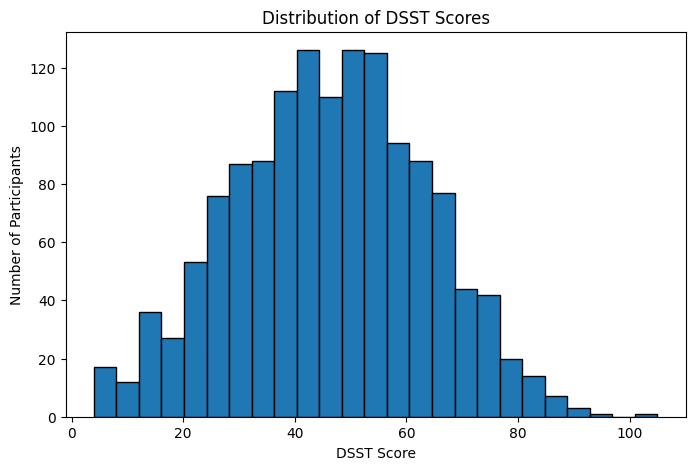

In [72]:
plt.figure(figsize=(8, 5))

plt.hist(dsst_df["CFDDS"], bins=25, edgecolor="black")

plt.xlabel("DSST Score")
plt.ylabel("Number of Participants")
plt.title("Distribution of DSST Scores")

plt.show()

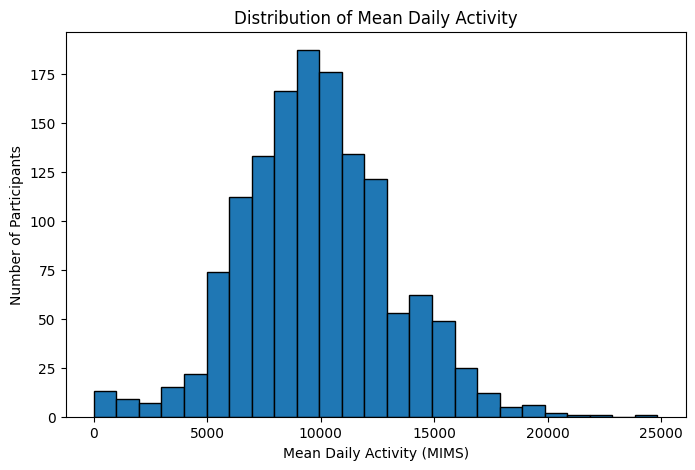

In [73]:
plt.figure(figsize=(8, 5))

plt.hist(
    dsst_df["mean_daily_activity"],
    bins=25,
    edgecolor="black"
)

plt.xlabel("Mean Daily Activity (MIMS)")
plt.ylabel("Number of Participants")
plt.title("Distribution of Mean Daily Activity")

plt.show()

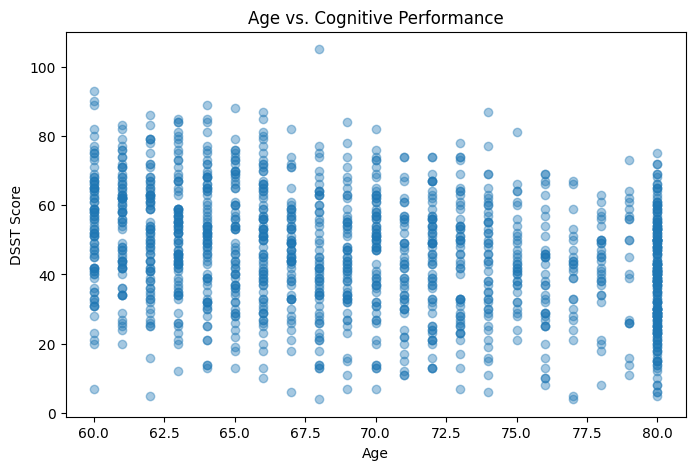

In [74]:
plt.figure(figsize=(8, 5))

plt.scatter(
    dsst_df["RIDAGEYR"],
    dsst_df["CFDDS"],
    alpha=0.4
)

plt.xlabel("Age")
plt.ylabel("DSST Score")
plt.title("Age vs. Cognitive Performance")

plt.show()

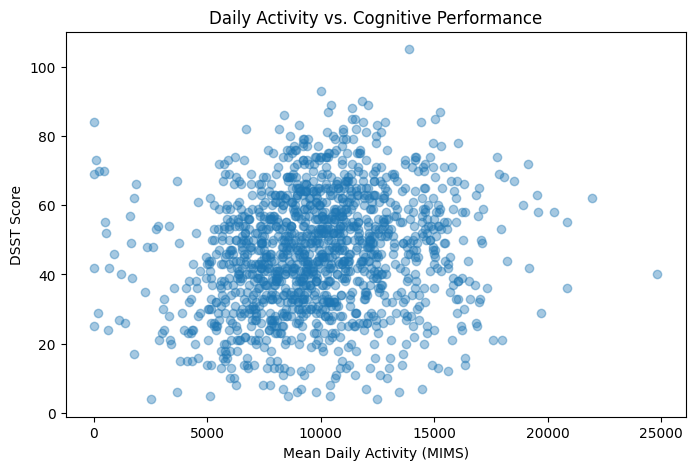

In [75]:
plt.figure(figsize=(8, 5))

plt.scatter(
    dsst_df["mean_daily_activity"],
    dsst_df["CFDDS"],
    alpha=0.4
)

plt.xlabel("Mean Daily Activity (MIMS)")
plt.ylabel("DSST Score")
plt.title("Daily Activity vs. Cognitive Performance")

plt.show()

### Preliminary Correlation Analysis

Pearson correlations were calculated to examine preliminary linear associations between cognitive performance, wearable-derived activity features, and age.

In [76]:
correlation_vars = [
    "CFDDS",
    "RIDAGEYR",
    "mean_daily_activity",
    "activity_sd",
    "activity_cv",
    "mean_wake_wear_minutes",
    "mean_sleep_wear_minutes"
]

correlations = dsst_df[correlation_vars].corr()

correlations.round(3)

,CFDDS,RIDAGEYR,mean_daily_activity,activity_sd,activity_cv,mean_wake_wear_minutes,mean_sleep_wear_minutes
CFDDS,1.000,-0.290,0.174,0.145,0.017,0.093,-0.091
RIDAGEYR,-0.290,1.000,-0.312,-0.346,-0.072,-0.139,0.222
mean_daily_activity,0.174,-0.312,1.000,0.740,-0.336,0.736,-0.322
activity_sd,0.145,-0.346,0.740,1.000,0.115,0.327,-0.381
activity_cv,0.017,-0.072,-0.336,0.115,1.000,-0.647,-0.320
mean_wake_wear_minutes,0.093,-0.139,0.736,0.327,-0.647,1.000,-0.246
mean_sleep_wear_minutes,-0.091,0.222,-0.322,-0.381,-0.320,-0.246,1.000


In [77]:
from scipy.stats import pearsonr

variables = [
    "RIDAGEYR",
    "mean_daily_activity",
    "activity_sd",
    "activity_cv",
    "mean_wake_wear_minutes",
    "mean_sleep_wear_minutes"
]

for variable in variables:
    r, p = pearsonr(
        dsst_df[variable],
        dsst_df["CFDDS"]
    )

    print(
        f"{variable}: "
        f"r = {r:.3f}, "
        f"p = {p:.4g}"
    )

RIDAGEYR: r = -0.290, p = 2.531e-28
mean_daily_activity: r = 0.174, p = 7.745e-11
activity_sd: r = 0.145, p = 6.142e-08
activity_cv: r = 0.017, p = 0.5314
mean_wake_wear_minutes: r = nan, p = nan
mean_sleep_wear_minutes: r = nan, p = nan


In [78]:
dsst_df[
    [
        "mean_wake_wear_minutes",
        "mean_sleep_wear_minutes"
    ]
].describe()

,mean_wake_wear_minutes,mean_sleep_wear_minutes
count,1382.000000,1380.000000
mean,736.618248,452.703879
std,138.267790,118.715151
min,2.375000,3.222222
25%,680.444444,390.722222
50%,759.277778,450.777778
75%,820.687500,513.031250
max,1025.222222,1086.750000


In [79]:
print(
    "Wake missing:",
    dsst_df["mean_wake_wear_minutes"].isna().sum()
)

print(
    "Sleep missing:",
    dsst_df["mean_sleep_wear_minutes"].isna().sum()
)

Wake missing: 4
Sleep missing: 6


In [80]:
print(
    "Wake unique:",
    dsst_df["mean_wake_wear_minutes"].nunique()
)

print(
    "Sleep unique:",
    dsst_df["mean_sleep_wear_minutes"].nunique()
)

Wake unique: 1221
Sleep unique: 1216


In [81]:
from scipy.stats import pearsonr

for variable in [
    "mean_wake_wear_minutes",
    "mean_sleep_wear_minutes"
]:

    temp = dsst_df[
        [variable, "CFDDS"]
    ].dropna()

    r, p = pearsonr(
        temp[variable],
        temp["CFDDS"]
    )

    print(
        f"{variable}: n = {len(temp)}, "
        f"r = {r:.3f}, p = {p:.4g}"
    )

mean_wake_wear_minutes: n = 1382, r = 0.093, p = 0.0005481
mean_sleep_wear_minutes: n = 1380, r = -0.091, p = 0.0007377


In [82]:
r, p = pearsonr(
    dsst_df["RIDAGEYR"],
    dsst_df["mean_daily_activity"]
)

print(
    f"Age vs. mean daily activity: "
    f"r = {r:.3f}, p = {p:.4g}"
)

Age vs. mean daily activity: r = -0.312, p = 1.184e-32


In [83]:
education_dsst = (
    dsst_df
    .groupby("DMDEDUC2")["CFDDS"]
    .agg(["count", "mean", "std", "median"])
)

education_dsst.round(2)

,count,mean,std,median
DMDEDUC2,,,,
1.0,125,24.82,12.83,24.0
2.0,185,37.97,13.73,37.0
3.0,345,44.61,14.53,44.0
4.0,402,50.95,15.17,51.0
5.0,329,55.22,15.25,56.0


In [84]:
education_labels = {
    1: "<9th grade",
    2: "9–11th grade",
    3: "High school/GED",
    4: "Some college/AA",
    5: "College graduate+"
}

In [85]:
education_dsst.index = education_dsst.index.map(
    education_labels
)

education_dsst

,count,mean,std,median
DMDEDUC2,,,,
<9th grade,125,24.816000,12.829769,24.0
9–11th grade,185,37.972973,13.726138,37.0
High school/GED,345,44.611594,14.532637,44.0
Some college/AA,402,50.950249,15.165998,51.0
College graduate+,329,55.218845,15.254972,56.0


## 9. Statistical Modeling

Multiple linear regression models were used to determine whether wearable-derived activity features are associated with cognitive performance after accounting for demographic characteristics.

A baseline demographic model was first constructed using age, sex, and education. Wearable-derived activity features were subsequently added to determine whether they provide additional explanatory value beyond demographic predictors.

In [86]:
import statsmodels.formula.api as smf

In [87]:
model_1 = smf.ols(
    "CFDDS ~ RIDAGEYR + C(RIAGENDR) + C(DMDEDUC2)",
    data=dsst_df
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  CFDDS   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     139.4
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          3.93e-138
Time:                        00:57:59   Log-Likelihood:                -5568.6
No. Observations:                1386   AIC:                         1.115e+04
Df Residuals:                    1379   BIC:                         1.119e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             77.7326      3

In [89]:
model_2 = smf.ols(
    """CFDDS ~ RIDAGEYR
             + C(RIAGENDR)
             + C(DMDEDUC2)
             + mean_daily_activity""",
    data=dsst_df
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  CFDDS   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     125.7
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          5.94e-143
Time:                        00:58:47   Log-Likelihood:                -5554.9
No. Observations:                1386   AIC:                         1.113e+04
Df Residuals:                    1378   BIC:                         1.117e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              65.0601    

In [90]:
dsst_df["activity_per_1000"] = (
    dsst_df["mean_daily_activity"] / 1000
)

In [91]:
model_2 = smf.ols(
    """CFDDS ~ RIDAGEYR
             + C(RIAGENDR)
             + C(DMDEDUC2)
             + activity_per_1000""",
    data=dsst_df
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  CFDDS   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     125.7
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          5.94e-143
Time:                        00:59:19   Log-Likelihood:                -5554.9
No. Observations:                1386   AIC:                         1.113e+04
Df Residuals:                    1378   BIC:                         1.117e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             65.0601      4

In [92]:
model_3 = smf.ols(
    """CFDDS ~ RIDAGEYR
             + C(RIAGENDR)
             + C(DMDEDUC2)
             + activity_per_1000
             + activity_cv""",
    data=dsst_df
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  CFDDS   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     110.3
Date:                Thu, 27 Aug 2026   Prob (F-statistic):          2.65e-142
Time:                        00:59:39   Log-Likelihood:                -5553.9
No. Observations:                1386   AIC:                         1.113e+04
Df Residuals:                    1377   BIC:                         1.117e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             62.1491      5

In [93]:
comparison = pd.DataFrame({
    "Model": [
        "Demographics",
        "Demographics + Activity",
        "Demographics + Activity + Variability"
    ],
    "R_squared": [
        model_1.rsquared,
        model_2.rsquared,
        model_3.rsquared
    ],
    "Adjusted_R_squared": [
        model_1.rsquared_adj,
        model_2.rsquared_adj,
        model_3.rsquared_adj
    ],
    "AIC": [
        model_1.aic,
        model_2.aic,
        model_3.aic
    ]
})

comparison.round(4)

,Model,R_squared,Adjusted_R_squared,AIC
0,Demographics,0.3775,0.3748,11151.2694
1,Demographics + Activity,0.3897,0.3866,11125.7295
2,Demographics + Activity + Variability,0.3906,0.3871,11125.7907


### Preliminary Findings

The baseline demographic model explained approximately 37.7% of the variance in DSST cognitive performance. Adding mean daily wearable-measured activity increased the explained variance to approximately 39.0%.

After adjustment for age, sex, and education, higher mean daily activity remained significantly associated with better DSST performance. Each additional 1,000 MIMS units of mean daily activity was associated with approximately 0.61 points higher DSST score.

Adding relative day-to-day activity variability (activity CV) provided minimal additional explanatory value and was not independently associated with DSST performance.

These preliminary findings suggest that overall wearable-derived activity level may provide modest information about cognitive performance beyond basic demographic characteristics, whereas relative day-to-day activity variability does not appear to provide substantial additional information.